In [1]:
import pandas as pd

# IBM Telco dataset: one row per customer; Churn = did they leave last month
# the notebook sits in notebooks/, so "../" goes up to reach data/
df = pd.read_csv("../data/Telco-Customer-Churn.csv")

# (rows, columns) -> rows are customers
print(df.shape)
df.head()

(7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


**What I see**
- 7043 customers, 21 columns: customerID, 19 features, and Churn (the target, Yes/No).
- customerID is a label only; drop it before modelling.
- Most columns are Yes/No text; SeniorCitizen is already 0/1.
- tenure = months as a customer, likely a strong churn signal.
- "No phone service" / "No internet service" repeat what PhoneService / InternetService already say.

In [2]:
# type of every column and how many non-empty values it has
# watch for a column that should be a number but shows up as object (text)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


**What I see**
- No NaN in any column (7043 non-null everywhere).
- TotalCharges is stored as text (object) although it's money, so some values can't be read as numbers. Probably blanks, which pandas doesn't count as missing.
- MonthlyCharges is already a number (float64).

In [4]:
# Find the values that break TotalCharges

# try to turn every value into a number; errors="coerce" turns failures into NaN
total = pd.to_numeric(df["TotalCharges"], errors="coerce")

# the rows that failed, with their tenure and charges, to see what they have in common
bad = total.isna()
print(bad.sum(), "rows could not be converted")
df.loc[bad, ["customerID", "tenure", "MonthlyCharges", "TotalCharges"]]

11 rows could not be converted


,customerID,tenure,MonthlyCharges,TotalCharges
488,4472-LVYGI,0,52.55,
753,3115-CZMZD,0,20.25,
936,5709-LVOEQ,0,80.85,
1082,4367-NUYAO,0,25.75,
1340,1371-DWPAZ,0,56.05,
3331,7644-OMVMY,0,19.85,
3826,3213-VVOLG,0,25.35,
4380,2520-SGTTA,0,20.00,
5218,2923-ARZLG,0,19.70,
6670,4075-WKNIU,0,73.35,


**What I see**
- 11 rows have a blank TotalCharges, and all 11 have tenure 0: brand-new customers who haven't been billed yet.
- The blank means "nothing charged so far", so the correct value is 0, not a median.
- Decision: convert TotalCharges to a number and fill these 11 with 0 (a fixed rule, safe before the split).

In [5]:
# Fix TotalCharges



# tenure 0 = new customers not billed yet, so their total so far is 0
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce").fillna(0)

# check: now a number, and exactly the 11 new customers have 0
print(df["TotalCharges"].dtype, "|", (df["TotalCharges"] == 0).sum(), "customers with 0 total")

float64 | 11 customers with 0 total


In [9]:
# How many customers left?


# customers who left vs stayed, as counts and as shares of all customers
print(df["Churn"].value_counts())
print(df["Churn"].value_counts(normalize=True).round(3).map("{:.1%}".format))

Churn
No     5174
Yes    1869
Name: count, dtype: int64
Churn
No     73.5%
Yes    26.5%
Name: proportion, dtype: object


**What I see**
- 5,174 stayed (73.5%), 1,869 left (26.5%): about 1 in 4 customers churned.
- Always predicting "No" would be 73.5% accurate and catch zero churners, so accuracy is misleading here.
- I'll judge models with Average Precision (random baseline ~0.265), plus precision and recall.

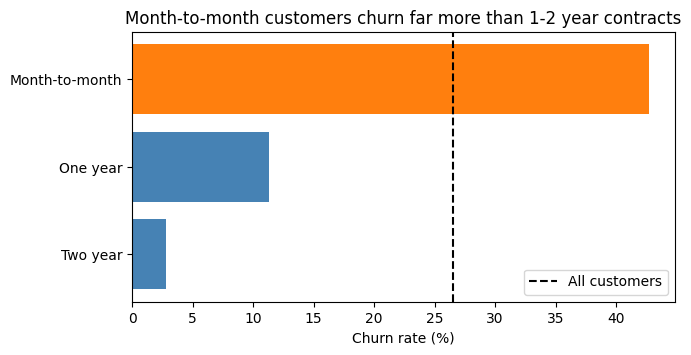

In [10]:
# Churn rate by contract type


import matplotlib.pyplot as plt

# churn rate per contract = % of customers in that group who left
churned = df["Churn"] == "Yes"
rate = churned.groupby(df["Contract"]).mean().sort_values() * 100

# orange = the highest-risk group, dashed line = the overall churn rate
colors = ["tab:orange" if v == rate.max() else "steelblue" for v in rate.values]
fig, ax = plt.subplots(figsize=(7, 3.5))
ax.barh(rate.index, rate.values, color=colors)
ax.axvline(churned.mean() * 100, color="black", linestyle="--", label="All customers")
ax.set_title("Month-to-month customers churn far more than 1-2 year contracts")
ax.set_xlabel("Churn rate (%)")
ax.legend()
plt.show()

**What I see**
- Month-to-month customers churn at ~43%, one-year at ~11%, two-year at ~3% (average 26.5%).
- Month-to-month is the highest-risk group by far, about 15x the two-year rate.
- This is correlation, not proof: month-to-month customers may differ in other ways (newer, more price-sensitive). Contract must go into the model as a category.

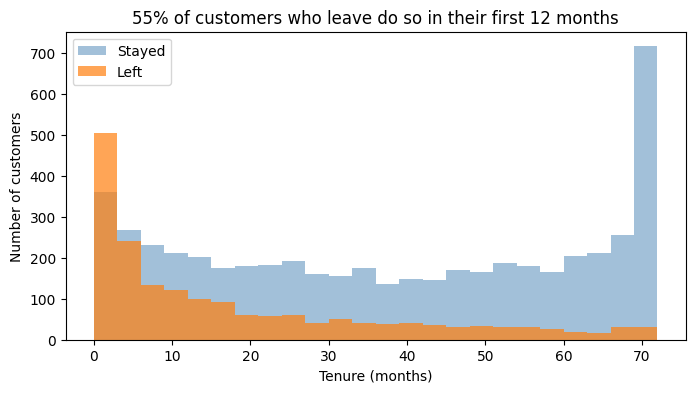

In [15]:
# Tenure for customers who left vs stayed


# same bins for both groups, so the bars line up and can be compared
bins = range(0, 75, 3)

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(df.loc[~churned, "tenure"], bins=bins, alpha=0.5, color="steelblue", label="Stayed")
ax.hist(df.loc[churned, "tenure"], bins=bins, alpha=0.7, color="tab:orange", label="Left")
ax.set_title("55% of customers who leave do so in their first 12 months")
ax.set_xlabel("Tenure (months)")
ax.set_ylabel("Number of customers")
ax.legend()
plt.show()

In [14]:
# of all customers who left, what share left within their first 12 months?
early_share = (df.loc[churned, "tenure"] <= 12).mean()
print(f"{early_share:.1%} of churners left within 12 months")

55.5% of churners left within 12 months


**What I see**
- 55.5% of churners left within their first 12 months; the first 3 months are the riskiest (more leave than stay).
- Churn falls steadily with tenure; long-time customers (60+ months) rarely leave.
- Business angle: the first year, especially the first 3 months, is where retention effort matters most.
- I checked the title's claim with a number instead of trusting my eye.

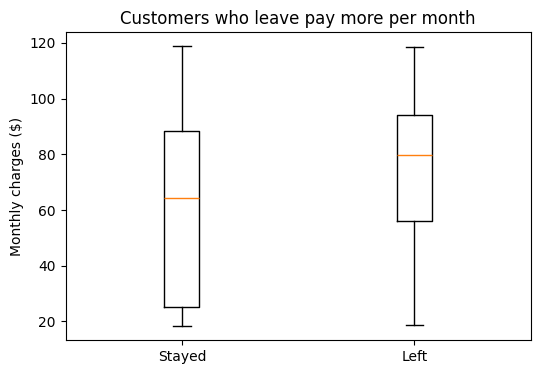

In [16]:
# Monthly charges, left vs stayed

# one box per group; the line inside each box is the median
groups = [df.loc[~churned, "MonthlyCharges"], df.loc[churned, "MonthlyCharges"]]

fig, ax = plt.subplots(figsize=(6, 4))
ax.boxplot(groups, tick_labels=["Stayed", "Left"])
ax.set_title("Customers who leave pay more per month")
ax.set_ylabel("Monthly charges ($)")
plt.show()

**What I see**
- Median monthly charge: ~$80 for customers who left vs ~$64 for those who stayed.
- Many stayers pay very little (~$25): simple, cheap plans rarely churn.
- The boxes overlap heavily, so price alone can't separate the groups; the model has to combine features.

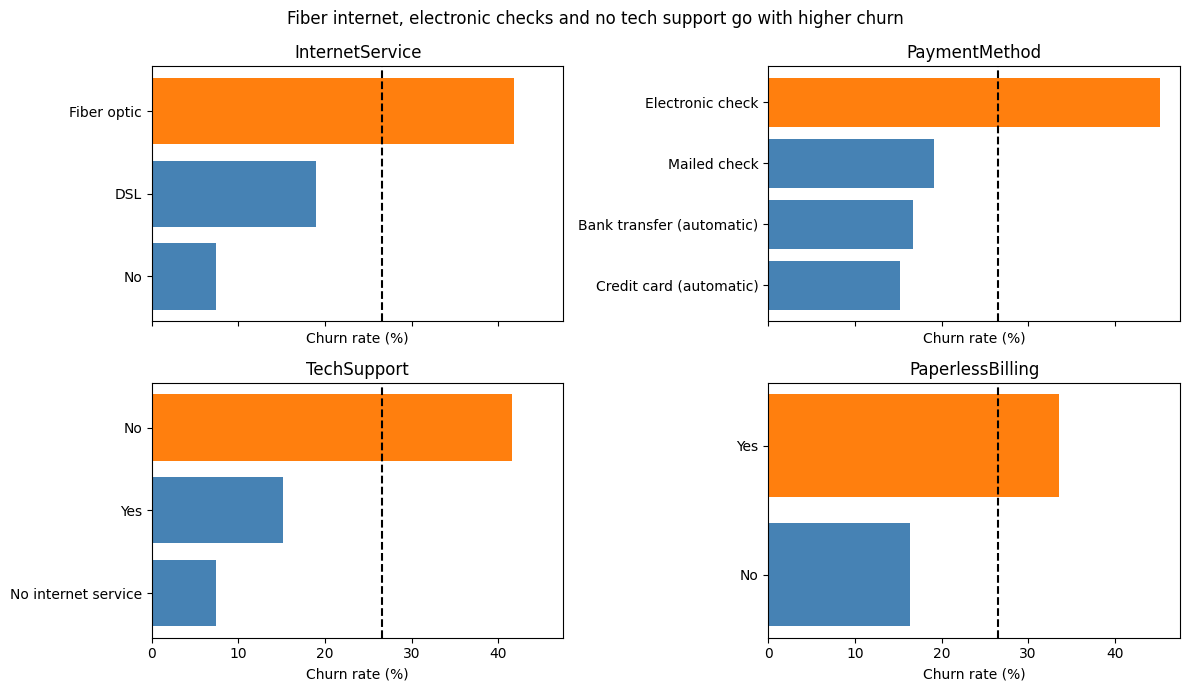

In [18]:
# Churn rate across 4 features at once (2×2 grid)

cols = ["InternetService", "PaymentMethod", "TechSupport", "PaperlessBilling"]
avg = churned.mean() * 100

fig, axes = plt.subplots(2, 2, figsize=(12, 7),sharex = True)
for col, ax in zip(cols, axes.flat):
    # churn rate per group; orange = above the overall average
    rate = churned.groupby(df[col]).mean().sort_values() * 100
    ax.barh(rate.index, rate.values, color=["tab:orange" if v > avg else "steelblue" for v in rate.values])
    ax.axvline(avg, color="black", linestyle="--")
    ax.set_title(col)
    ax.set_xlabel("Churn rate (%)")

fig.suptitle("Fiber internet, electronic checks and no tech support go with higher churn")
plt.tight_layout()
plt.show()

**What I see**
- Fiber optic (~42%), electronic check (~45%), no tech support (~42%) and paperless billing (~34%) all churn above the 26.5% average.
- Automatic payments (bank transfer, credit card) churn ~15-17%, so paying manually goes with leaving.
- "No internet service" churns least (~7%): the same phone-only customers repeated across many columns.
- Panels now share one x-axis scale so bar lengths compare fairly.

In [19]:
# How related are the 3 number columns?


# correlation between the three number columns (-1 to +1)
df[["tenure", "MonthlyCharges", "TotalCharges"]].corr().round(2)

,tenure,MonthlyCharges,TotalCharges
tenure,1.00,0.25,0.83
MonthlyCharges,0.25,1.00,0.65
TotalCharges,0.83,0.65,1.00


**What I see**
- tenure and TotalCharges correlate at 0.83: TotalCharges is roughly tenure x MonthlyCharges.
- tenure and MonthlyCharges barely relate (0.25), so they carry different information.
- Decision: keep all three. Correlated features don't hurt predictions much (regularized logistic regression, trees), but I'll be careful reading individual coefficients.

### Features and target

In [20]:
# target as 1/0: 1 = left, 0 = stayed (models need numbers, not "Yes"/"No")
y = (df["Churn"] == "Yes").astype(int)

# customerID is only a label and Churn is the answer; everything else is a feature
X = df.drop(columns=["customerID", "Churn"])
print(X.shape, "| churn rate:", round(y.mean(), 3))

(7043, 19) | churn rate: 0.265


In [21]:
# Train/test split, now stratified

from sklearn.model_selection import train_test_split

# 20% held out for the final check; stratify=y keeps 26.5% churners in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42)

print(X_train.shape, X_test.shape)
print("Churn rate - train:", round(y_train.mean(), 3), "| test:", round(y_test.mean(), 3))

(5634, 19) (1409, 19)
Churn rate - train: 0.265 | test: 0.265


### The preparation pipeline



In [22]:
from sklearn.pipeline import make_pipeline
from sklearn.compose import make_column_transformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

num_cols = X_train.select_dtypes("number").columns
cat_cols = X_train.select_dtypes("object").columns

# numbers: same scale for every column; text: one 0/1 column per category
prep = make_column_transformer(
    (StandardScaler(), num_cols),
    (OneHotEncoder(handle_unknown="ignore"), cat_cols))

print(len(num_cols), "number columns:", list(num_cols))
print(len(cat_cols), "text columns")

4 number columns: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']
15 text columns


### Baseline and the first real model

In [24]:
from sklearn.model_selection import cross_val_score
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression

# baseline: gives every customer the same 26.5% churn chance (no skill)
# logistic regression: weighted sum of features -> sigmoid -> probability
models = {"Baseline": DummyClassifier(strategy="prior"),
          "Logistic Regression": LogisticRegression(max_iter=1000)}

results = {}
for name, model in models.items():
    # for classifiers, cv=5 automatically keeps the churn rate the same in every fold
    scores = cross_val_score(make_pipeline(prep, model), X_train, y_train, cv=5, scoring="average_precision")
    results[name] = scores.mean()
    print(f"{name}: AP {scores.mean():.3f} (+/- {scores.std():.3f})")

Baseline: AP 0.265 (+/- 0.000)
Logistic Regression: AP 0.662 (+/- 0.028)


**What I see**
- Baseline AP 0.265 = the churn rate: no ranking skill, same in every fold.
- Logistic regression AP 0.662 (+/- 0.028): about 2.5x the baseline.
- Differences between models smaller than ~0.03 may be fold noise.

In [26]:
# A small helper, and the decision tree

from sklearn.tree import DecisionTreeClassifier

# same pipeline, same folds, same metric for every model, so they compare fairly
def cv_ap(name, model):
    scores = cross_val_score(make_pipeline(prep, model), X_train, y_train, cv=5, scoring="average_precision")
    results[name] = scores.mean()
    print(f"{name}: AP {scores.mean():.3f} (+/- {scores.std():.3f})")

# no depth limit: keeps splitting until every leaf is pure -> memorizes the training data
cv_ap("Decision Tree (no limit)", DecisionTreeClassifier(random_state=42))
# depth 5: at most 5 questions in a row
cv_ap("Decision Tree (depth 5)", DecisionTreeClassifier(max_depth=5, random_state=42))

Decision Tree (no limit): AP 0.360 (+/- 0.010)
Decision Tree (depth 5): AP 0.600 (+/- 0.028)


**What I see**
- Unlimited tree: AP 0.360, barely above baseline. It memorized the training data (overfitting), and its pure leaves give only 0% or 100%, which can't rank customers.
- Depth-5 tree: AP 0.600. Limiting depth keeps only general patterns.
- Still below logistic regression (0.662): a single tree is a rough, unstable model.

In [27]:
# Random Forest

from sklearn.ensemble import RandomForestClassifier

# 300 trees, each on a random sample of rows and features; predictions are averaged
# min_samples_leaf=5: every leaf needs at least 5 customers, so no leaf memorizes one person
# n_jobs=-1: use all CPU cores to train faster
cv_ap("Random Forest", RandomForestClassifier(n_estimators=300, min_samples_leaf=5,
                                              random_state=42, n_jobs=-1))

Random Forest: AP 0.663 (+/- 0.032)


**What I see**
- Random Forest AP 0.663, up from 0.600 for a single tree: averaging many trees cancels much of their individual overfitting.
- It ties logistic regression (0.662); the 0.001 difference is far inside the ~0.03 fold noise.
- Hint: the churn signal may be mostly additive, which a linear model already captures.

In [28]:
# XGBoost (gradient boosting)

from xgboost import XGBClassifier

# 300 small trees built in sequence, each correcting the errors of the ones before
# learning_rate=0.05: each tree only corrects a little, which is slower but more careful
# subsample / colsample_bytree: each tree sees 80% of rows and features, which adds variety
cv_ap("XGBoost", XGBClassifier(n_estimators=300, learning_rate=0.05, max_depth=3,
                               subsample=0.8, colsample_bytree=0.8, random_state=42))

XGBoost: AP 0.667 (+/- 0.030)


**What I see**
- XGBoost AP 0.667, Random Forest 0.663, Logistic Regression 0.662: a three-way tie inside the ~0.03 fold noise.
- Boosting (trees in sequence) didn't clearly beat bagging (trees in parallel) or a linear model here.

In [29]:
# K-Nearest Neighbours (KNN)


from sklearn.neighbors import KNeighborsClassifier

# k=5: probabilities can only be 0, 0.2, 0.4, 0.6, 0.8 or 1 (6 possible values)
cv_ap("KNN (k=5)", KNeighborsClassifier(n_neighbors=5))
# k=50: probabilities in steps of 0.02, so customers can be ranked much more finely
cv_ap("KNN (k=50)", KNeighborsClassifier(n_neighbors=50))

KNN (k=5): AP 0.508 (+/- 0.016)
KNN (k=50): AP 0.624 (+/- 0.028)


**What I see**
- KNN k=5: AP 0.508, k=50: AP 0.624. Small k gives coarse, noisy probabilities (overfits); larger k smooths them.
- Still below the top three (~0.66): distances are blunt with many one-hot columns, and prediction is slow because every customer is compared with all training customers.

In [30]:
# Support Vector Machine (SVM)

from sklearn.svm import SVC

# RBF kernel: allows a curved boundary
# C=1.0: how strictly it avoids mistakes on training data (higher = stricter, can overfit)
cv_ap("SVM (RBF)", SVC(kernel="rbf", C=1.0))

SVM (RBF): AP 0.644 (+/- 0.027)


**What I see**
- SVM (RBF, untuned): AP 0.644, slightly below the top three (~0.66), within fold noise.
- Scales poorly to large data (training time grows fast with rows) and gives distances, not probabilities, by default.

In [31]:
# Neural network (MLP)


from sklearn.neural_network import MLPClassifier

# 2 hidden layers: 32 neurons, then 16
# alpha: penalty on large weights (like Ridge), to limit overfitting
# early_stopping: keeps 10% of the training fold aside and stops when that score stops improving
cv_ap("MLP (32, 16)", MLPClassifier(hidden_layer_sizes=(32, 16), alpha=1e-3, max_iter=500,
                                    early_stopping=True, random_state=42))

MLP (32, 16): AP 0.651 (+/- 0.029)
